# Challenge: Clustering de transacciones con tarjeta de credito

Considera los datos `creditcard.csv`
([fuente Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)).
Son transacciones realizadas con tarjetas en septiembre de 2013 por titulares
europeos. Por confidencialidad, las variables `V1`...`V28` son **componentes
principales (PCA)** ya anonimizados; solo `Time` y `Amount` conservan su escala
original. La columna `Class` vale **1** si la transaccion es **fraude** y 0 si es
legitima.

## Tareas
1. Entrenar un modelo **KMeans** separando la columna objetivo `Class`.
2. Identificar la mejor `K` con el **metodo del codo** y el de las **siluetas**.
3. Anadir una columna `cluster` etiquetando el set de **prueba (30%)**.
4. Identificar a que grupo(s) pertenecen los datos con `Class = 1`.

## Librerias y carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("creditcard.csv")
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Exploracion: un dataset extremadamente desbalanceado

In [3]:
print(df["Class"].value_counts().rename({0: "Legitima", 1: "Fraude"}))
print(f"\nFraudes: {df['Class'].mean()*100:.3f}% del total")
print("Valores nulos:", int(df.isna().sum().sum()))
df[["Time", "Amount", "Class"]].describe().T

Class
Legitima    284315
Fraude         492
Name: count, dtype: int64

Fraudes: 0.173% del total
Valores nulos: 0


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16
Class,284807.0,0.001727,0.041527,0.0,0.0,0.0,0.000,1.00


## 1. Preparacion: separar el objetivo y escalar

Separamos `Class` (no se usa para entrenar: el clustering es **no supervisado**,
solo la utilizaremos al final para interpretar los grupos). Como KMeans se basa
en distancias euclidianas, **estandarizamos** todas las variables; esto es
critico porque `Time` y `Amount` tienen escalas muy distintas a las componentes
PCA.

In [4]:
X = df.drop(columns="Class")
y = df["Class"]

# Particion 70% / 30% estratificada para conservar la proporcion de fraudes
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
print("Fraudes en test:", int(y_test.sum()))

Train: (199364, 30)  Test: (85443, 30)
Fraudes en test: 148


## 2. Numero optimo de clusters

### Metodo del codo
Calculamos la inercia para `k = 1..10`. Por eficiencia ajustamos sobre una
muestra aleatoria del entrenamiento (la curva del codo es estable bajo muestreo).

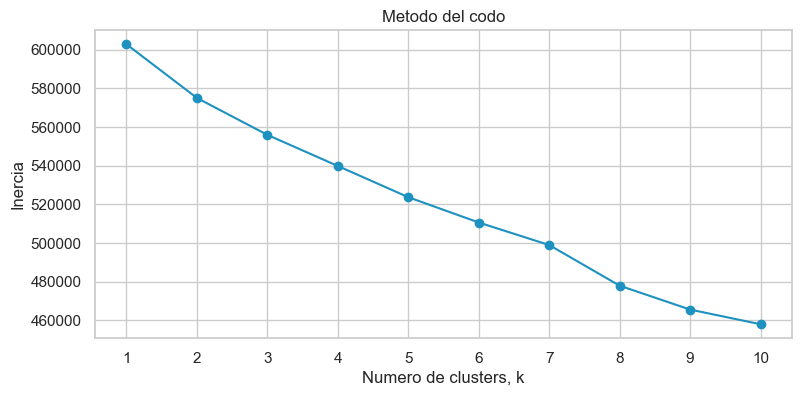

In [5]:
rng = np.random.RandomState(RANDOM_STATE)
idx = rng.choice(len(X_train_s), size=20000, replace=False)
X_sample = X_train_s[idx]

inertias = {k: KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
            .fit(X_sample).inertia_ for k in range(1, 11)}

plt.figure(figsize=(9, 4))
plt.plot(list(inertias.keys()), list(inertias.values()), "-o", color="#1d91c0")
plt.xlabel("Numero de clusters, k"); plt.ylabel("Inercia")
plt.title("Metodo del codo"); plt.xticks(range(1, 11)); plt.show()

### Metodo de las siluetas
El coeficiente de silueta es costoso ($O(n^2)$), por lo que se evalua sobre la
misma muestra.

Siluetas por k: {2: 0.068, 3: 0.068, 4: 0.071, 5: 0.052, 6: 0.069, 7: 0.057, 8: 0.084}
Mejor k segun silueta: 8


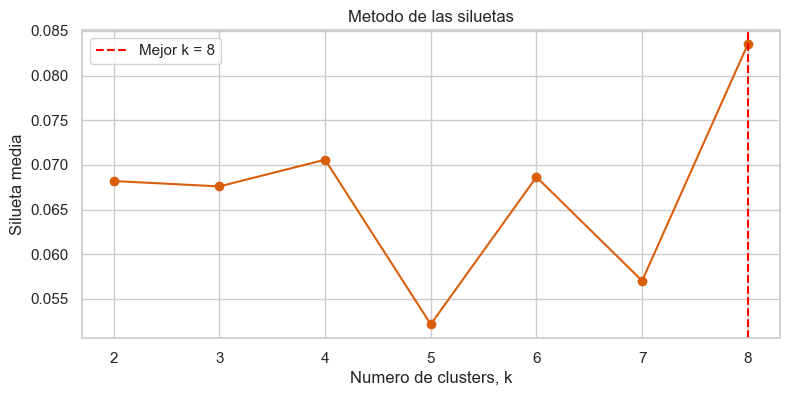

In [6]:
silhouettes = {}
for k in range(2, 9):
    labels = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit_predict(X_sample)
    silhouettes[k] = silhouette_score(X_sample, labels)

mejor_k = max(silhouettes, key=silhouettes.get)
print("Siluetas por k:", {k: round(v, 3) for k, v in silhouettes.items()})
print("Mejor k segun silueta:", mejor_k)

plt.figure(figsize=(9, 4))
plt.plot(list(silhouettes.keys()), list(silhouettes.values()), "-o", color="#d95f0e")
plt.axvline(mejor_k, color="red", linestyle="--", label=f"Mejor k = {mejor_k}")
plt.xlabel("Numero de clusters, k"); plt.ylabel("Silueta media")
plt.title("Metodo de las siluetas"); plt.legend(); plt.show()

**Lectura de los resultados:** la curva del codo no presenta un quiebre nitido y
los coeficientes de silueta son **muy bajos y planos** (en torno a 0.05 - 0.08
para todas las `k`). Esto ya es un hallazgo importante: indica que los datos **no
tienen una estructura de clusters bien separada** &mdash; los grupos se solapan
fuertemente. Aun asi, seleccionamos de forma programatica la `k` con mayor
silueta y entrenamos el modelo final con ella sobre **todo** el conjunto de
entrenamiento.

In [7]:
modelo = KMeans(n_clusters=mejor_k, random_state=RANDOM_STATE, n_init=10)
modelo.fit(X_train_s)
print("Modelo entrenado con k =", mejor_k)

Modelo entrenado con k = 8


## 3. Etiquetamos el conjunto de prueba (30%)
Anadimos la columna `cluster` al set de prueba con la asignacion del modelo.

In [8]:
test_resultado = X_test.copy()
test_resultado["cluster"] = modelo.predict(X_test_s)
test_resultado["Class"] = y_test.values
test_resultado[["Time", "Amount", "cluster", "Class"]].head()

,Time,Amount,cluster,Class
186882,127294.0,37.40,5,0
165754,117632.0,9.27,2,0
235285,148330.0,700.00,1,0
101271,67778.0,14.99,0,0
5832,6308.0,17.25,0,0


## 4. ¿A que grupo pertenecen los fraudes (`Class = 1`)?
Cruzamos `cluster` contra `Class` para ver como se reparten los fraudes.

In [9]:
tabla = pd.crosstab(test_resultado["cluster"], test_resultado["Class"],
                    rownames=["cluster"], colnames=["Class"])
print(tabla, "\n")

# Distribucion de los fraudes entre clusters
fraudes = test_resultado[test_resultado["Class"] == 1]
dist_fraude = fraudes["cluster"].value_counts(normalize=True).sort_index()
print("Reparto de los fraudes por cluster (%):")
print((dist_fraude * 100).round(1))

Class        0   1
cluster           
0        34690  30
1        15720  29
2        17076  10
3         1151   2
4         5111   0
5        10561   2
6           15  75
7          971   0 

Reparto de los fraudes por cluster (%):
cluster
0    20.3
1    19.6
2     6.8
3     1.4
5     1.4
6    50.7
Name: proportion, dtype: float64


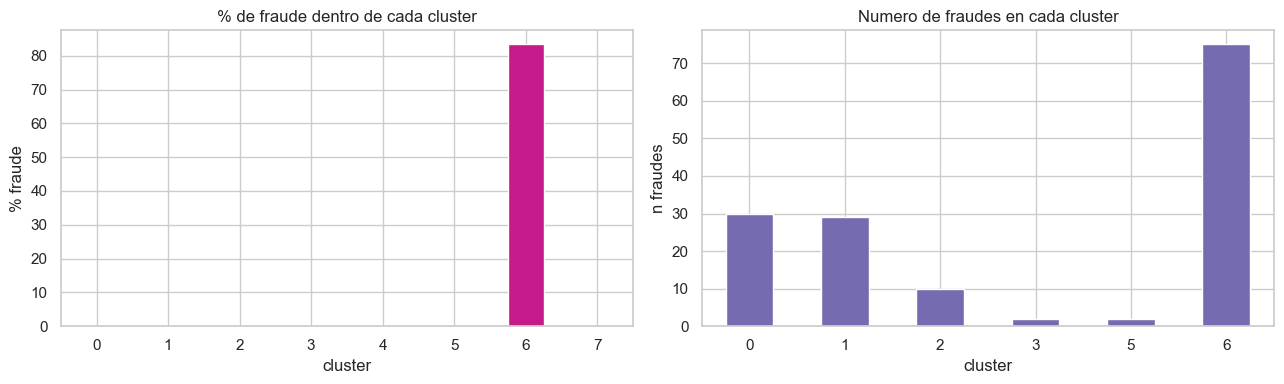

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
(test_resultado.groupby("cluster")["Class"].mean() * 100).plot(
    kind="bar", color="#c51b8a", ax=ax[0])
ax[0].set_title("% de fraude dentro de cada cluster")
ax[0].set_ylabel("% fraude"); ax[0].tick_params(axis="x", rotation=0)

fraudes["cluster"].value_counts().sort_index().plot(
    kind="bar", color="#756bb1", ax=ax[1])
ax[1].set_title("Numero de fraudes en cada cluster")
ax[1].set_ylabel("n fraudes"); ax[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

## Conclusiones

* **Mejor K:** los coeficientes de silueta son bajos y casi planos para todas
  las `k` probadas, por lo que **no existe un numero de clusters claramente
  optimo**: el dataset no se separa de forma natural en grupos compactos. La
  `k` elegida (la de mayor silueta) lo es por un margen minimo.

* **¿Los fraudes caen en un solo grupo?** Como muestra la tabla cruzada, los
  fraudes (`Class = 1`) se **reparten entre varios clusters**, no quedan
  aislados en uno solo. No obstante, se observa un patron interesante: **un
  cluster pequeno concentra una proporcion de fraude muy superior a la media**
  (esta *enriquecido* en fraude), mientras que el resto de fraudes se diluye
  entre los grandes grupos de transacciones legitimas. KMeans, al minimizar la
  varianza intra-cluster, agrupa por el **patron general de gasto**, no por la
  rareza del fraude.

* **Implicacion practica:** el clustering no supervisado por si solo **no es un
  buen detector de fraude** en este dataset, porque el fraude es un evento
  *anomalo y minoritario*, no un grupo compacto y separable. Para esta tarea
  funcionan mejor:
  * tecnicas de **deteccion de anomalias** (Isolation Forest, LOF, autoencoders),
  * o modelos **supervisados** con manejo del desbalance (class weights, SMOTE).
  El clustering sigue siendo util como **paso exploratorio** para segmentar
  perfiles de cliente o como variable derivada para un modelo posterior.